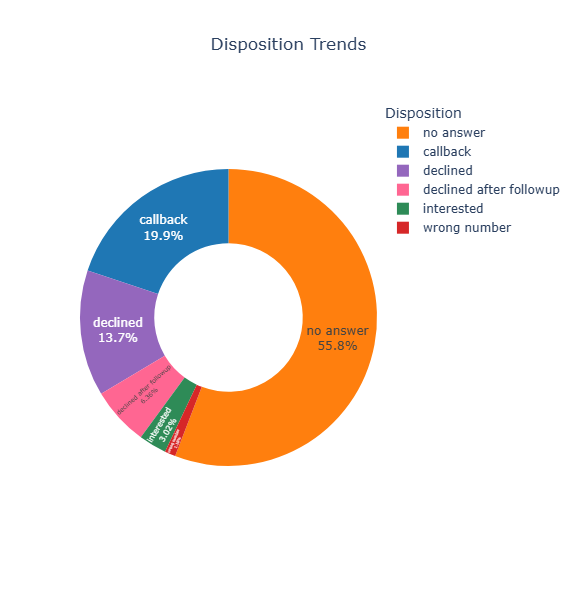

In [ ]:
import pandas as pd
import plotly.express as px

sheet_id = input("Enter Google Sheet ID: ")
sheet_name = input("Enter Sheet Name: ")
gid = input("Enter GID")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)


df["Disposition"] = (
    df["Disposition"]
    .astype(str)
    .str.strip()
    .str.lower()
)


disposition_count = (
    df["Disposition"]
    .value_counts()
    .reset_index()
)

disposition_count.columns = ["Disposition", "Count"]


fig = px.pie(
    disposition_count,
    names="Disposition",
    values="Count",
    hole=0.5,
    title="Disposition Trends",
    color="Disposition",
    color_discrete_map={
        "interested": "#2E8B57",             
        "callback": "#1F77B4",               
        "wrong number": "#D62728",           
        "no answer": "#FF7F0E",              
        "declined": "#9467BD",               
        "declined after follow up": "#8C564B" 
    }
)



fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hovertemplate="<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=800,
    title_x=0.5,
    legend_title="Disposition"
)

fig.show()